In [47]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading the txt file

In [2]:
f = open("WhatsApp Chat with Research paper.txt", 'r', encoding='utf-8')

In [3]:
data = f.read()

In [4]:
print(type(data))

<class 'str'>


In [5]:
print(data)

09/04/2026, 5:35 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*
09/04/2026, 5:35 pm - Girish created group "Research paper"
09/04/2026, 5:35 pm - Girish added you
09/04/2026, 5:38 pm - Girish: sabbei ko college email deuna
09/04/2026, 5:38 pm - Girish: @⁨all⁩
09/04/2026, 5:38 pm - @Mrpramez: Np05cp4a250002@iic.edu.np
09/04/2026, 5:40 pm - Girish: Comparative analysis of AI-generated code vs student-written code in efficiency and correctness
09/04/2026, 5:41 pm - Girish: kastoo cha
09/04/2026, 5:41 pm - Girish: yo
09/04/2026, 6:02 pm - @Mrpramez: Good topic
09/04/2026, 6:07 pm - Girish: aaejeii ramroo khojam naa
09/04/2026, 6:46 pm - Panda Thapaliya: np05cp4a250016@iic.edu.np
10/04/2026, 9:15 am - @Mrpramez: Topic - Detecting dark patterns in web UI using machine learning

Question - can a DOM based classifier reliably detect the top 5 most common dark patterns on e-commerce websites? <This message was edited>


Data filtering

In [6]:
date_pattern = r"\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}(?:\s(?:am|pm|AM|PM))?"
entry_pattern = (
    r"(?s)^" +
    r"(" + date_pattern + r")" +
    r"\s-\s([^:]+):\s(.*?)" +
    r"(?=\n" + date_pattern + r"\s-\s[^:]+:\s|\Z)"
)

In [7]:
entries = re.findall(entry_pattern, data, flags=re.M)
messages = [f"{name}: {msg}" for _, name, msg in entries]
messages[:5]


['Girish: sabbei ko college email deuna',
 'Girish: @\u2068all\u2069',
 '@Mrpramez: Np05cp4a250002@iic.edu.np',
 'Girish: Comparative analysis of AI-generated code vs student-written code in efficiency and correctness',
 'Girish: kastoo cha']

In [8]:
dates = [
    re.sub(r"\s(?:am|pm|AM|PM)$", "", d.replace("\u202f", " ")) + " - "
    for d, _, _ in entries
]
dates[:5]

['09/04/2026, 5:38 - ',
 '09/04/2026, 5:38 - ',
 '09/04/2026, 5:38 - ',
 '09/04/2026, 5:40 - ',
 '09/04/2026, 5:41 - ']

Creating a dataframe

In [9]:
df = pd.DataFrame({"user_message": messages, "message_date": dates})
clean_dates = df["message_date"].str.replace(r"\s-\s$", "", regex=True)
df["message_date"] = pd.to_datetime(clean_dates, format="mixed", dayfirst=True)
df.rename(columns={"message_date": "date"}, inplace=True)

In [10]:
df.head()

,user_message,date
0,Girish: sabbei ko college email deuna,2026-04-09 05:38:00
1,Girish: @⁨all⁩,2026-04-09 05:38:00
2,@Mrpramez: Np05cp4a250002@iic.edu.np,2026-04-09 05:38:00
3,Girish: Comparative analysis of AI-generated c...,2026-04-09 05:40:00
4,Girish: kastoo cha,2026-04-09 05:41:00


In [11]:
df.shape

(175, 2)

Seperate users and messages

In [12]:
users = []
messages = []
for message in df['user_message']:
    entry = re.split('([\w\W]+?):\s', message)
    if entry[1:]:
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])
df['user'] = users
df['message'] = messages
df.drop(columns=['user_message'], inplace=True)            

<>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\prafu\AppData\Local\Temp\ipykernel_5932\1680902730.py:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  entry = re.split('([\w\W]+?):\s', message)


In [13]:
df.head()

,date,user,message
0,2026-04-09 05:38:00,Girish,sabbei ko college email deuna
1,2026-04-09 05:38:00,Girish,@⁨all⁩
2,2026-04-09 05:38:00,@Mrpramez,Np05cp4a250002@iic.edu.np
3,2026-04-09 05:40:00,Girish,Comparative analysis of AI-generated code vs s...
4,2026-04-09 05:41:00,Girish,kastoo cha


Extracting year, month, date and time 

In [14]:
df['year']= df['date'].dt.year

In [15]:
df['month'] =df['date'].dt.month_name()

In [16]:
df['day'] = df['date'].dt.day

In [17]:
df['hour'] = df['date'].dt.hour

In [18]:
df['minute'] = df['date'].dt.minute

In [19]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2026-04-09 05:38:00,Girish,sabbei ko college email deuna,2026,April,9,5,38
1,2026-04-09 05:38:00,Girish,@⁨all⁩,2026,April,9,5,38
2,2026-04-09 05:38:00,@Mrpramez,Np05cp4a250002@iic.edu.np,2026,April,9,5,38
3,2026-04-09 05:40:00,Girish,Comparative analysis of AI-generated code vs s...,2026,April,9,5,40
4,2026-04-09 05:41:00,Girish,kastoo cha,2026,April,9,5,41


Number of messages

In [27]:
# Gives total number of messages in the whole group
df['user'].shape[0]

175

In [20]:
df['user'].unique()

<ArrowStringArray>
['Girish', '@Mrpramez', 'Panda Thapaliya', 'GauravDulal', 'Praful Dhakal']
Length: 5, dtype: str

In [28]:
#This gives the number of messages sent by a single user
df[df['user'] == "Praful Dhakal"].shape[0]

3

Number of Words

In [32]:
words = []
for message in df['message']:
    words.extend(message.split())

In [33]:
len(words)

594

Number of links

In [38]:
# Finds urls from the given string
from urlextract import URLExtract

In [37]:
extractor = URLExtract()
urls = extractor.find_urls("https://github.com/gyr0byte/OOP_Purity_Analyzer.git")
urls

['https://github.com/gyr0byte/OOP_Purity_Analyzer.git']

In [42]:
link = []
for message in df['message']:
    link.extend(extractor.find_urls(message))

In [43]:
link

['https://www.overleaf.com/7124766772tmgrsrjxqhbs#461871',
 'https://www.overleaf.com/7124766772tmgrsrjxqhbs#461871',
 'https://github.com/gyr0byte/OOP_Purity_Analyzer.git',
 'https://oop-purity-analyzer-1.onrender.com',
 'https://www.youtube.com/watch?v=eF7HoC-cLRM&list=PLaldQ9PzZd9qPYGj4aWUXitBlfWz72e9m&index=27']

In [44]:
len(link)

5

Most active users

In [45]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2026-04-09 05:38:00,Girish,sabbei ko college email deuna,2026,April,9,5,38
1,2026-04-09 05:38:00,Girish,@⁨all⁩,2026,April,9,5,38
2,2026-04-09 05:38:00,@Mrpramez,Np05cp4a250002@iic.edu.np,2026,April,9,5,38
3,2026-04-09 05:40:00,Girish,Comparative analysis of AI-generated code vs s...,2026,April,9,5,40
4,2026-04-09 05:41:00,Girish,kastoo cha,2026,April,9,5,41


In [49]:
x = df['user'].value_counts()

In [50]:
name = x.index
count = x.values

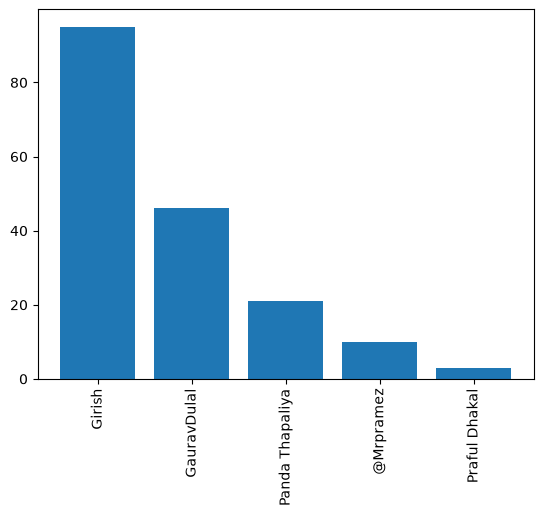

In [ ]:
plt.bar(name, count)
plt.xticks(rotation = 'vertical')
plt.show()

Active user by percentage of messages

In [58]:
round((df['user'].value_counts()/df.shape[0])*100 , 2).reset_index().rename(columns = {'index': 'name', 'count': 'percent'})

,user,percent
0,Girish,54.29
1,GauravDulal,26.29
2,Panda Thapaliya,12.00
3,@Mrpramez,5.71
4,Praful Dhakal,1.71
